### Gaussian Mixture Model (GMM) Explained and Coded from Scratch in Python
#### PI Marju Orho Melander, Lund University. NBIS: Nikolay Oskolkov, SciLifeLab, NBIS Long Term Support, [nikolay.oskolkov@scilifelab.se](nikolay.oskolkov@scilifelab.se)


<h3><center>Abstract</center></h3>
In this notebook we will some basics of clustering algorithms and particularily concentrate on the Gaussian Mixture Model (GMM) that we will explain and code from scratch in Python. We will demonstrate how probabilistic clustering algorithms such as GMM can infer optimal number of clusters from the data.

#### Table of Contents:
* [Overview of Clustering Methods](#Overview-of-Clustering-Methods)
* [K-Means Clustering from Scratch](#K-Means-Clustering-from-Scratch)
* [Gaussian Mixture Model (GMM) from Scratch](#Gaussian-Mixture-Model-(GMM)-from-Scratch)
* [Probabilistic Interpretation of GMM and AIC](#Probabilistic-Interpretation-of-GMM-and-AIC)

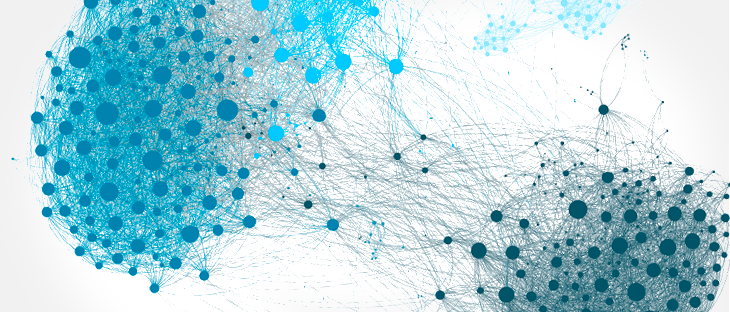

In [2]:
from IPython.display import Image
Image('/home/nikolay/WABI/Misc/Clustering/Graph_ok.png', width = 2000)

#### Overview of Clustering Methods <a class="anchor" id="Overview-of-Clustering-Methods"></a>

Clustering is a challenging problem with an outcome very sensitive to the choice of **1) distance metric between data points, 2) number of clusters, and 3) clustering algorithm**. All clustering algorithms experience difficulties working with high-dimensional data, but even for low-dimensional data many of them might fail due to internal assumtions and limitations of the algorithms.Python library scikit-learn provides a collection of clustering methods with an excellent overview which emphasizes their advantages and disadvantages.

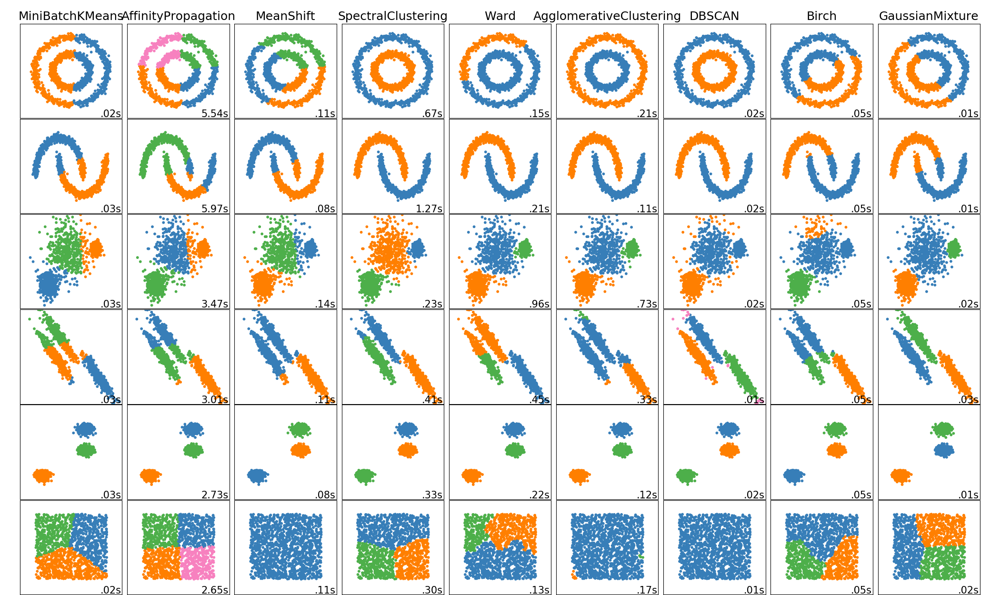

In [3]:
from IPython.display import Image
Image('/home/nikolay/WABI/Misc/Clustering/sphx_glr_plot_cluster_comparison_001.png', width = 2000)

All clustering methods can roughly be divided into four groups:

* **Hierarchical / agglomerative clustering (hclust, single linkage, complete linkage, UPGMA, Ward, Birch)**
* **Centroid-based / partitioning clustering (K-means, GMM, DMM, LDA)**
* **Density-based clustering (DBSCAN, HDBSCAN, mean-shift)**
* **Graph-based clustering (Spectral, SNN, Louvain, Leiden)**

Firts tow types of clustering algorithm are classical and have been known for years, while density-based and graph-based clustering is only now becoming more and more popular because of their robustness. Hierarchical (agglomerative) clustering is too sensitive to noise in the data. Centroid-based clustering (K-means, Gaussian Mixture Models) can handle only clusters with spherical or ellipsoidal symmetry.

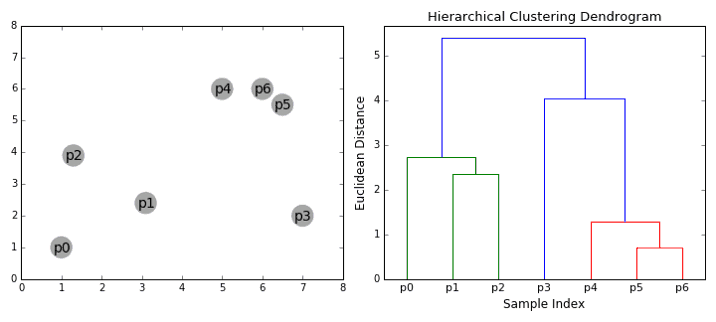

In [45]:
from IPython.display import Image
Image('/home/nikolay/WABI/Misc/Clustering/hclust.gif.png', width = 2000)

Hierarchical / agglomerative clustering starts with individual data points and collapses them together into clusters based on a certain condition when a data point can be added to an already existing cluster or start belong to a new cluster. Single linkage adds a data point to a cluster using the nearest neighbor from the cluster, while complete linkage uses the furtherst neighbor, while UPGMA uses the centroid of the cluster. Ward algorithm adds a data point to a cluster by using **least change in variation** as a criterion.

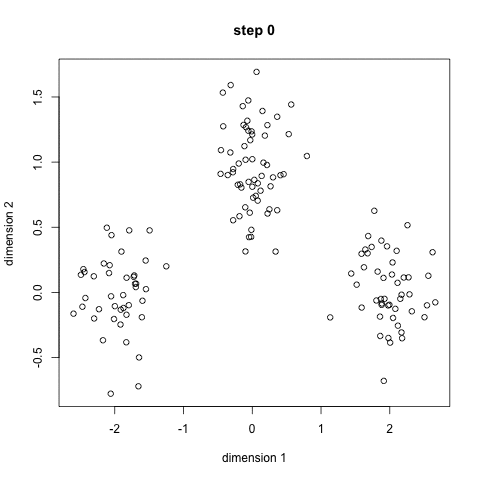

In [46]:
from IPython.display import Image
Image('/home/nikolay/WABI/Misc/Clustering/kmeans.gif.png', width = 2000)

In contrast to hierarchical / agglomerative clustering that starts from individual data points and therefore sensitive to outliers and noise, partitioning algorithms such as K-means, GMM and DMM try to make a rough split of the data points in the number of clusters specified by the user. Those algorithms can only address clusters of spherical or ellipsoidal symmetry. One starts with randomly placed centroids of the potential clusters, assigns each data point to a nearest centroid, and updates centroid positions by computing new centroids from the data points assigned to each centroid. 

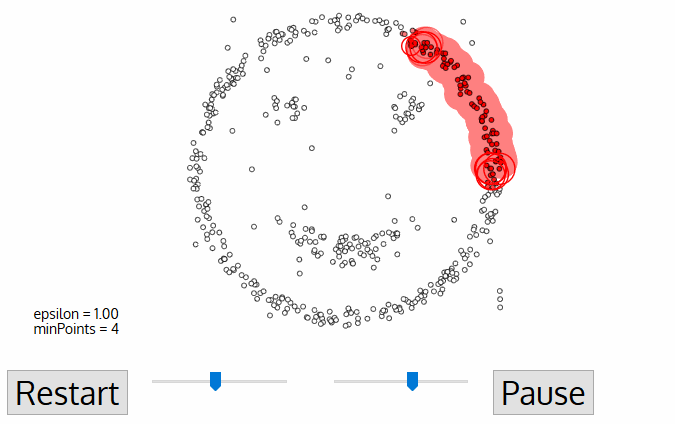

In [42]:
from IPython.display import Image
Image('/home/nikolay/WABI/Misc/Clustering/smiley_face.gif.png', width = 2000)

Density-based algorithms are probably the only group of clustering algorithms that does not need the number of clusters to be specified a-priori. In contrast, "travelling agents" are capable of finding dense regions of data points in a completely unsupervised way. The difficulty of those algorithms can only come from clusters of very different density. Otherwise, the size of the scanning window of the travelling agent can also be tuned from the data because DBSCAN and HDBSCAN are probabilistic algorithms that assign each data point to a cluster with a certain probability, that allows to use Akaike Information Criterion (AIC) to balance the goodness of fit and the number of fitting parameters and determine the optimal number of clusters.

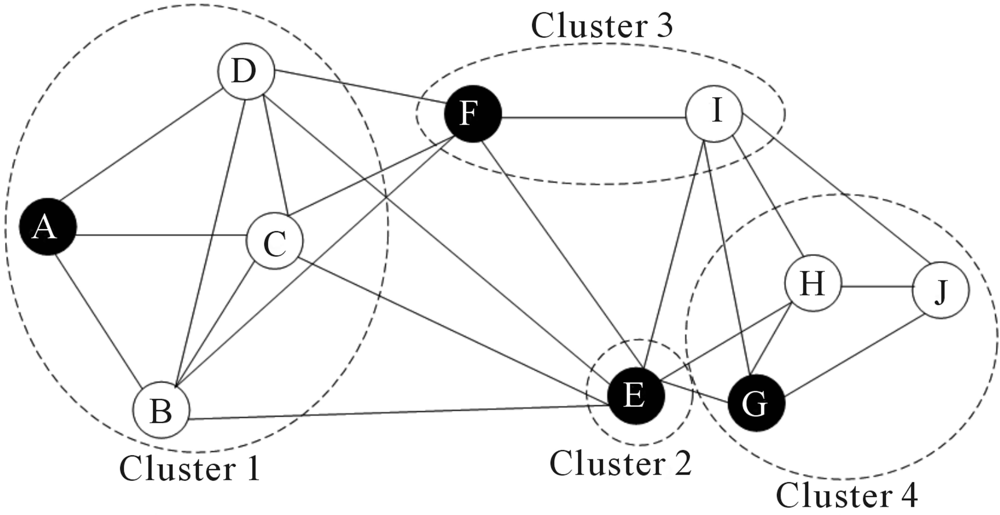

In [44]:
from IPython.display import Image
Image('/home/nikolay/WABI/Misc/Clustering/graph_network.jpg', width = 2000)

Graph-based clustering is probably the most robust with respect to real-world noisy problems since it replaces the real distances in the original data set by the distances on the graph in a non-parametric graph abstraction. For example for Shared Nearest Neighbors (SNN) algorithm, the distance between two data points is measured as a number of common intermediate nodes the two data points are sharing.

#### K-Means Clustering from Scratch <a class="anchor" id="K-Means-Clustering-from-Scratch"></a>

K-means has an interesting interpretation from the point of view of dimension reduction via matrix factorization. when we do dimension reduction via matrix factorization (e.g. PCA or MDS) we literaly decompose our data as a product of two matrices: scores (embeddings) and loadings (archetypes). It turns out that if we demand that each row of the U matrix contans only one non-zero element, we get nothing else as K-means clustering. In this case, the columns of the U matrix are the cluster labels and the matrix V is the centroids of the clusters.

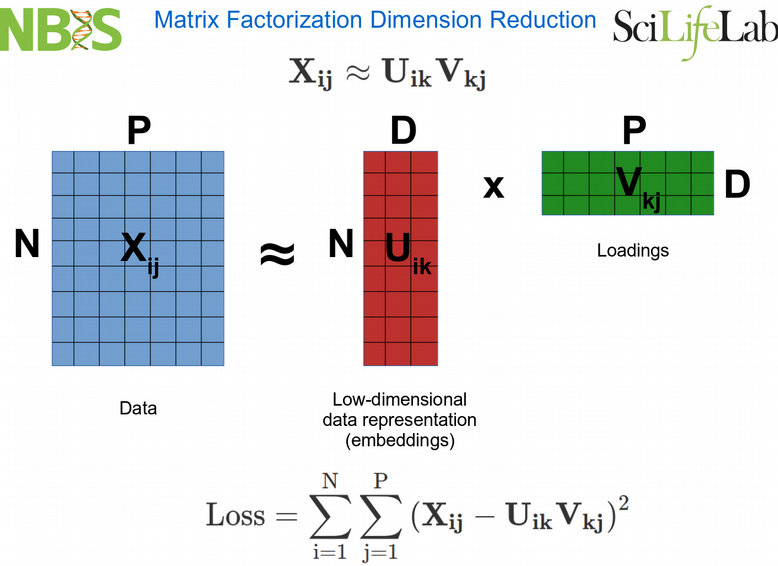

In [15]:
from IPython.display import Image
Image('/home/nikolay/WABI/MO_Melander/Presentation/DimReduct.png', width = 2000)

Let us implement the K-means clustering algorithm from scratch, it is quite simple to do. First, we will generate 2D ddata with 3 clusters.

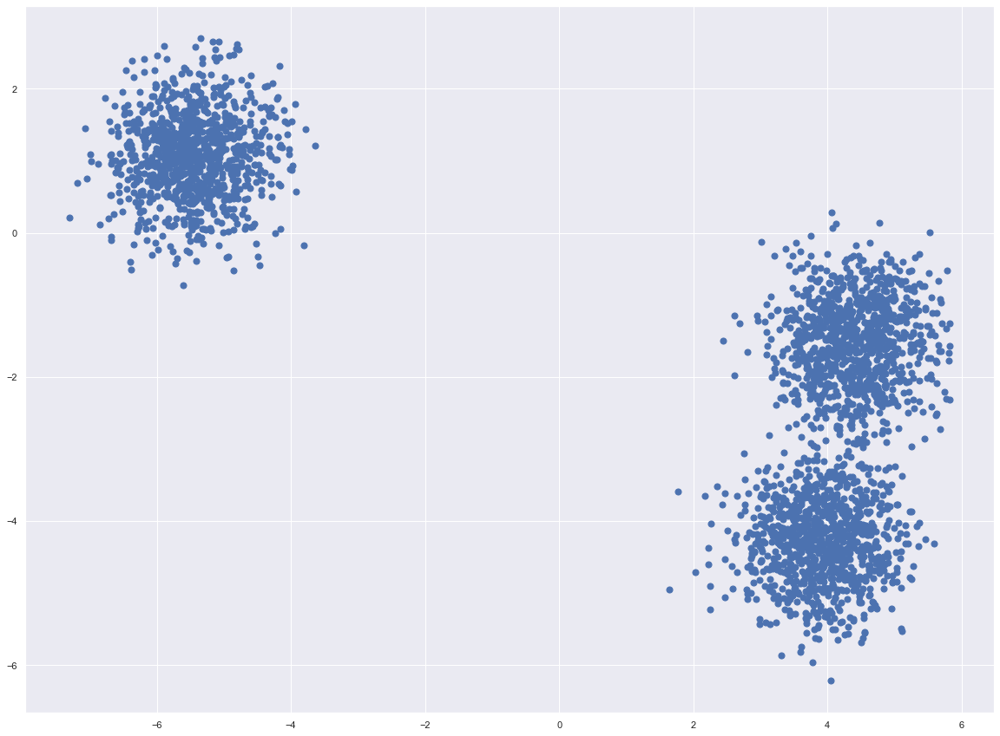

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.datasets.samples_generator import make_blobs

import warnings
warnings.filterwarnings("ignore")

plt.figure(figsize = (20,15))
X, y = make_blobs(n_samples = 3000, centers = 3, cluster_std = 0.6, random_state = 123)
plt.scatter(X[:, 0], X[:, 1], s = 50)
plt.show()

In [61]:
X

array([[-5.68342231,  1.37145894],
       [-5.77568969,  1.6126376 ],
       [ 3.21858922, -4.18962577],
       ...,
       [ 4.59640476, -4.16863901],
       [ 4.36452346, -1.86252132],
       [ 4.82677019, -3.6355777 ]])

In [62]:
y

array([1, 1, 0, ..., 0, 2, 0])

In [63]:
k = 3
my_centers = X[np.random.randint(X.shape[0], size = k), :]
my_centers

array([[ 4.24767256, -4.39638947],
       [ 3.38620355, -4.33032848],
       [-5.48965682,  1.00596212]])

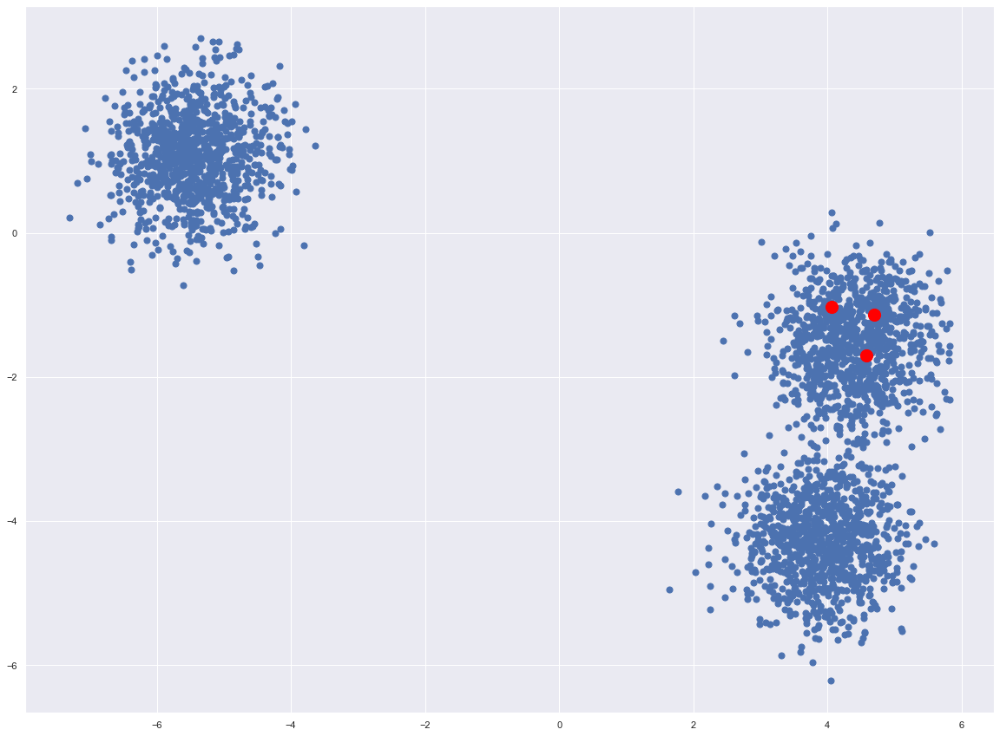

In [64]:
plt.figure(figsize = (20,15))
plt.scatter(X[:, 0], X[:, 1], s = 50)
plt.scatter(my_centers[:, 0], my_centers[:, 1], s = 200, c = 'red')
plt.show()

In [68]:
my_labels = list()
for i in range(X.shape[0]):
    my_dist = list()
    for j in range(k):
        my_dist.append(np.sqrt((X[i,:][0] - my_centers[j,:][0])**2 + (X[i,:][1] - my_centers[j,:][1])**2))
    my_labels.append(np.argmin(np.array(my_dist)))
my_labels = np.array(my_labels)
my_labels[0:10]

array([2, 2, 1, 2, 0, 2, 0, 2, 2, 0])

In [69]:
my_new_centers = np.array([X[my_labels == i].mean(axis = 0) for i in range(k)])
my_new_centers

array([[ 4.52595182, -2.7535627 ],
       [ 3.50479443, -3.17023249],
       [-5.45890634,  1.06970479]])

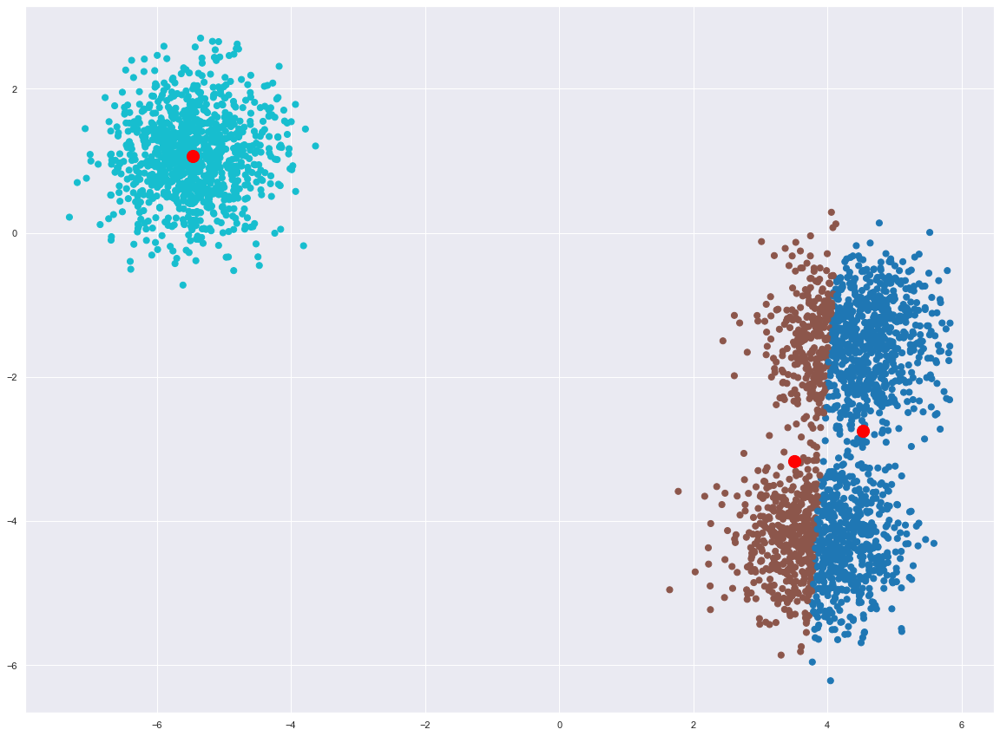

In [82]:
plt.figure(figsize = (20,15))
plt.scatter(X[:, 0], X[:, 1], s = 50, c = my_labels, cmap = 'tab10')
plt.scatter(my_new_centers[:, 0], my_new_centers[:, 1], s = 200, c = 'red')
plt.show()

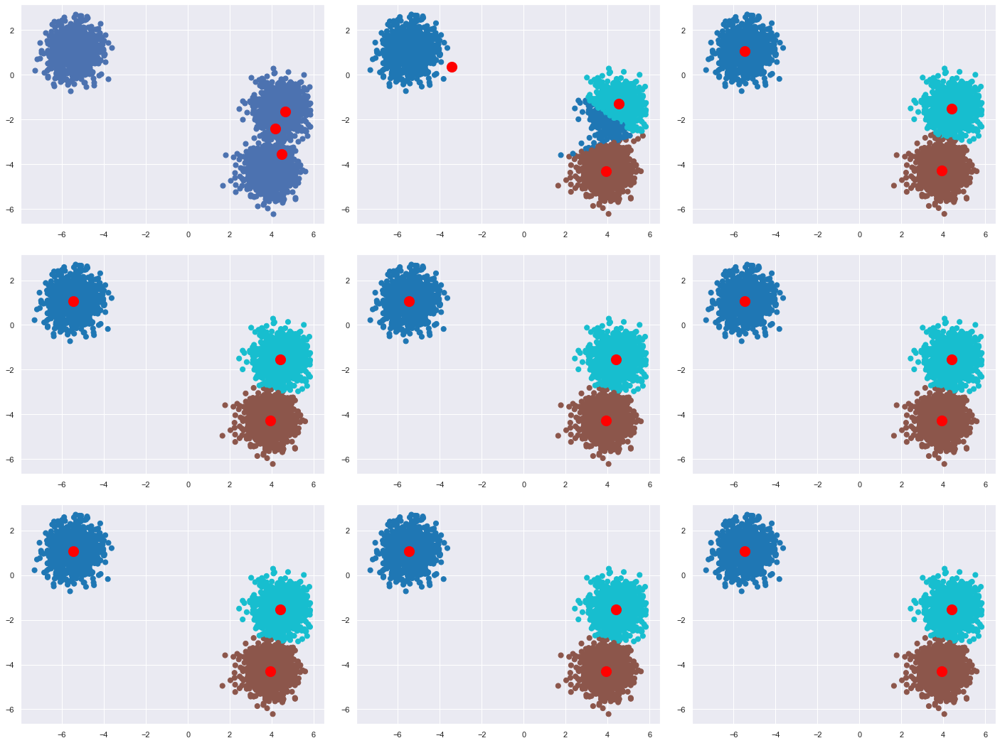

In [83]:
import matplotlib

figure = plt.figure(figsize = (20, 15))
matplotlib.rcParams.update({'font.size': 22})

k = 3
my_centers = X[np.random.randint(X.shape[0], size = k), :]

plt.subplot(331 + 0)
plt.scatter(X[:, 0], X[:, 1], s = 50)
plt.scatter(my_centers[:, 0], my_centers[:, 1], s = 200, c = 'red')

for m in range(1,9):
    
    my_labels = list()
    for i in range(X.shape[0]):
        my_dist = list()
        for j in range(k):
            my_dist.append(np.sqrt((X[i,:][0] - my_centers[j,:][0])**2 + (X[i,:][1] - my_centers[j,:][1])**2))
        my_labels.append(np.argmin(np.array(my_dist)))
    my_labels = np.array(my_labels)
    
    my_new_centers = np.array([X[my_labels == i].mean(axis = 0) for i in range(k)])
    
    plt.subplot(331 + m)
    plt.scatter(X[:, 0], X[:, 1], s = 50, c = my_labels, cmap = 'tab10')
    plt.scatter(my_new_centers[:, 0], my_new_centers[:, 1], s = 200, c = 'red')
    
    my_centers = my_new_centers

figure.tight_layout()
plt.show()

We can observe that K-means clustering algorithm seems to have convered after just three steps. So it worked great but please remember that we used spherical blobs of data points, i.e. the simplest possible simmetry. In case the blobs are at least a little bit elongated, assigning a data point to a cluster centroid with a Euclidean distance can fail as it is shown at the example below.

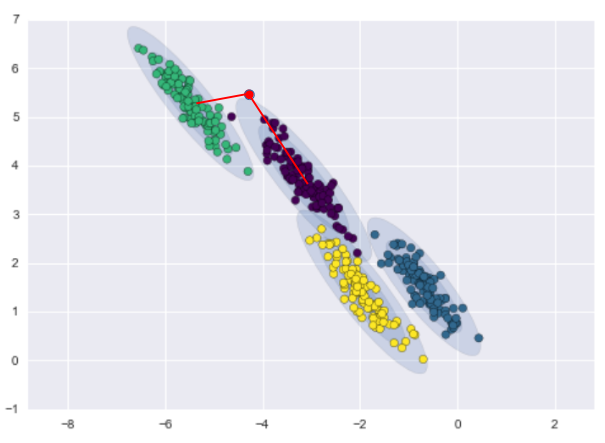

In [84]:
from IPython.display import Image
Image('/home/nikolay/Documents/ellipse.png', width = 2000)

Here it is natural to assign the red data point to the purple cluster. However, since the clusters are elingated, the distance from the read point to the center of the purple cluster happens to be larger than the distance between the red poin and the green cluster, so K-means algorithm would falsely assign the red point to the green cluster. To overcome this problem, one should use the Gaussian Mixture Model (GMM) clustering algorithm that we are going to cover in the next section.

#### Gaussian Mixture Model (GMM) from Scratch <a class="anchor" id="Gaussian-Mixture-Model-(GMM)-from-Scratch"></a>

Gaussian Mixture Model (GMM) is probably the most Bayesian clustering algorithm out of Maximum Likelihood algorithms. It belongs to the same partitioning group of algorithms as K-means but has two major advantages comapared to K-means- First, it takes variation in the data into account, i.e. is suitable for clusters with not only spherical but also ellipsoidal shape. Second, it has a probabilistic assignment of each data point to a cluster meaning that using Akaike Information Criterion (AIC) one has a chance to infer the optimal number of clusters from the data.

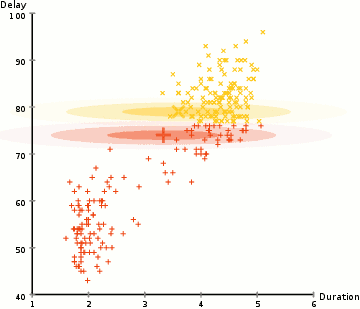

In [1]:
from IPython.display import Image
Image('/home/nikolay/WABI/Misc/Clustering/GMM.gif.png', width = 2000)

Here we will try to implement Gaussian Mixture Model (GMM) clustering algorithm for 1D and 2D cases. Let us first simulate a 1D data coming from 2 Gaussian distributions with different means and standard deviations. Here we will display the data points belonging to two Gaussians and the distributions themselves.

Dataset shape: (200,)


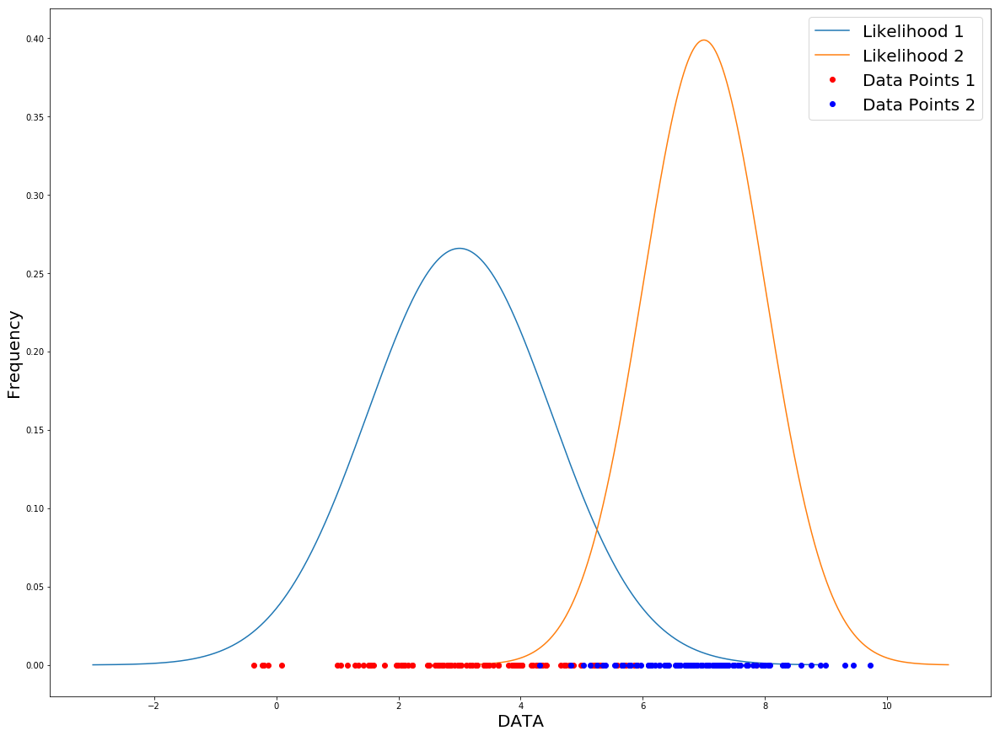

In [2]:
import random
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

n = 100
mu1 = 3; sigma1 = 1.5
mu2 = 7; sigma2 = 1

x1 = np.random.normal(mu1, sigma1, n)
x2 = np.random.normal(mu2, sigma2, n)
X = np.array(list(x1) + list(x2))
np.random.shuffle(X)
print("Dataset shape:", X.shape)

x1_approx = np.linspace(mu1 - 4*sigma1, mu1 + 4*sigma1, 10000)
x2_approx = np.linspace(mu2 - 4*sigma2, mu2 + 4*sigma2, 10000)
X_approx = np.array(list(x1_approx) + list(x2_approx))

def pdf(data, mean, sigma):
    return (1 / np.sqrt(2 * np.pi * sigma**2)) * np.exp( - (np.square(data - mean) / (2 * sigma**2)))

plt.figure(figsize = (20,15))
#plt.plot(x1_approx, norm.pdf(x1_approx, mu1, sigma1))
#plt.plot(x2_approx, norm.pdf(x2_approx, mu2, sigma2))
plt.plot(x1_approx, pdf(x1_approx, mu1, sigma1))
plt.plot(x2_approx, pdf(x2_approx, mu2, sigma2))

plt.plot(x1, list(0 for i in range(0, len(list(x1)))), 'ro')
plt.plot(x2, list(0 for i in range(0, len(list(x2)))), 'bo')

plt.ylabel('Frequency', fontsize = 20)
plt.xlabel('DATA', fontsize = 20)
plt.legend(['Likelihood 1', 'Likelihood 2','Data Points 1', 'Data Points 2'], loc = 'upper right', fontsize = 20)
plt.show()

Now we will implement Expectation-Maximization (EM) algorithm. For this purpose we will randomly guess initial values for means an the variances of the two clusters. Then we will use these initial values for computing likelihood of observing data. This is the expecation step step.

In [12]:
k = 2
np.random.seed(123)
means = np.random.choice(X, k)
sigmas = np.random.random_sample(size = k)
priors = np.ones((k)) / k
print(means, sigmas, priors)

[2.73272217 2.6378125 ] [0.42847093 0.69088486] [0.5 0.5]


$$L(X|\mu_k,\sigma_k)=\frac{1}{\sqrt{2\pi\sigma^2_k}}\rm{e}^{\displaystyle-\frac{(X-\mu_k)^2}{2\sigma^2_k}}$$

Once we computed the likelihood $L(X|\mu,\sigma)$, which we assume follows the Normal distribution, of observing the data given the parameters (means and variances), we can compute the posterior probability of data point assignment to each cluster using the Bayes rule.

$$\displaystyle p_{k}(\mu_k,\sigma_k|X)=\displaystyle\frac{\displaystyle L(X|\mu_k,\sigma_k)\phi_k(\mu_k,\sigma_k)}{\displaystyle\sum_k{L(X|\mu_k,\sigma_k)\phi_k(\mu_k,\sigma_k)}}$$

Next, differentiating the posterior probability with respect to the parameters, means and variances, i.e. by maximizing the posterior probability of the parameters given the data, we can derive an rule for updating the means and variances of the clusters.

$$\displaystyle\mu_k=\frac{\displaystyle\sum_i{X_i p_{k}(\mu_k,\sigma_k|X_i)}}{\displaystyle\sum_i{p_{k}(\mu_k,\sigma_k|X_i)}}, \,\,\,\,\, \sigma^2_k=\frac{\displaystyle\sum_i{(X_i-\mu_k)^2 p_{k}(\mu_k,\sigma_k|X_i)}}{\displaystyle\sum_i{p_{k}(\mu_k,\sigma_k|X_i)}}, \,\,\,\,\, \phi_k=\frac{1}{N}\sum_i{p_{k}(\mu_k,\sigma_k|X_i)}$$

2.7327221726844124 2.637812495673104
0.4284709261868257 0.6908848550268617


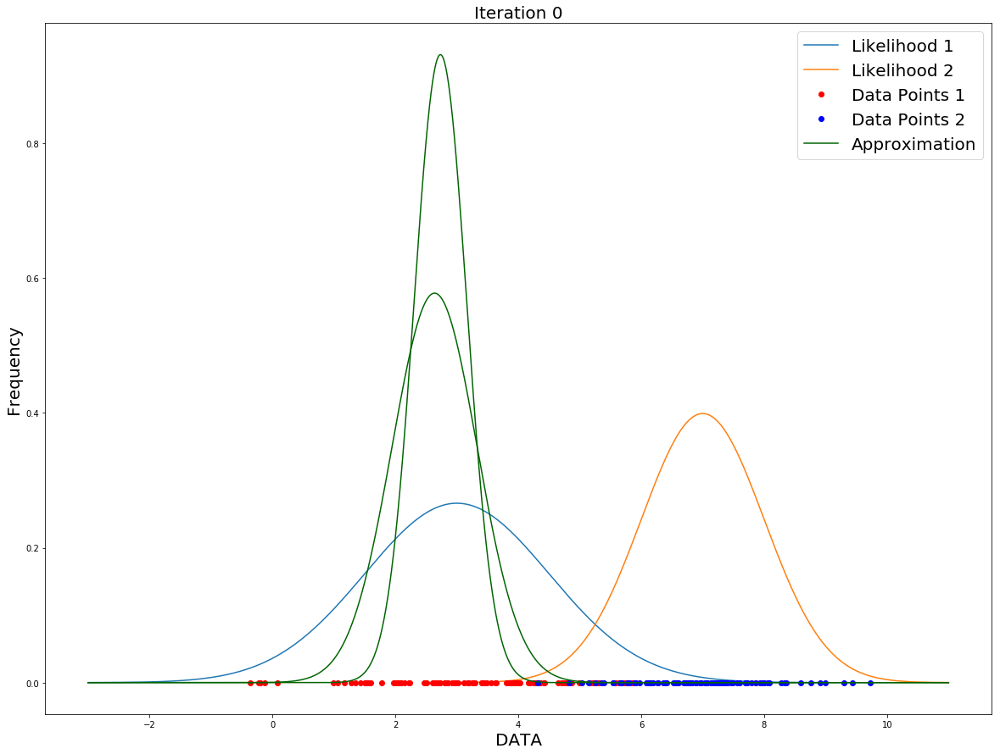

2.1964548206741825 5.407363593262624
0.7901617282889958 2.14058606190234


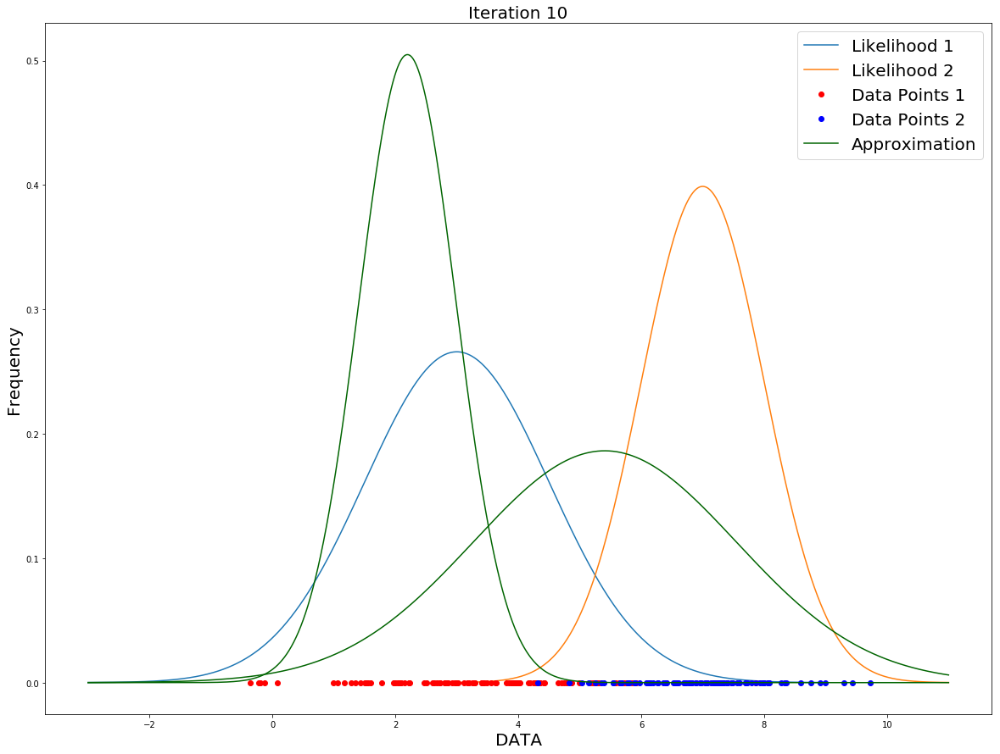

1.885669784001164 5.675462262481247
1.1259951871581104 1.9048773114368716


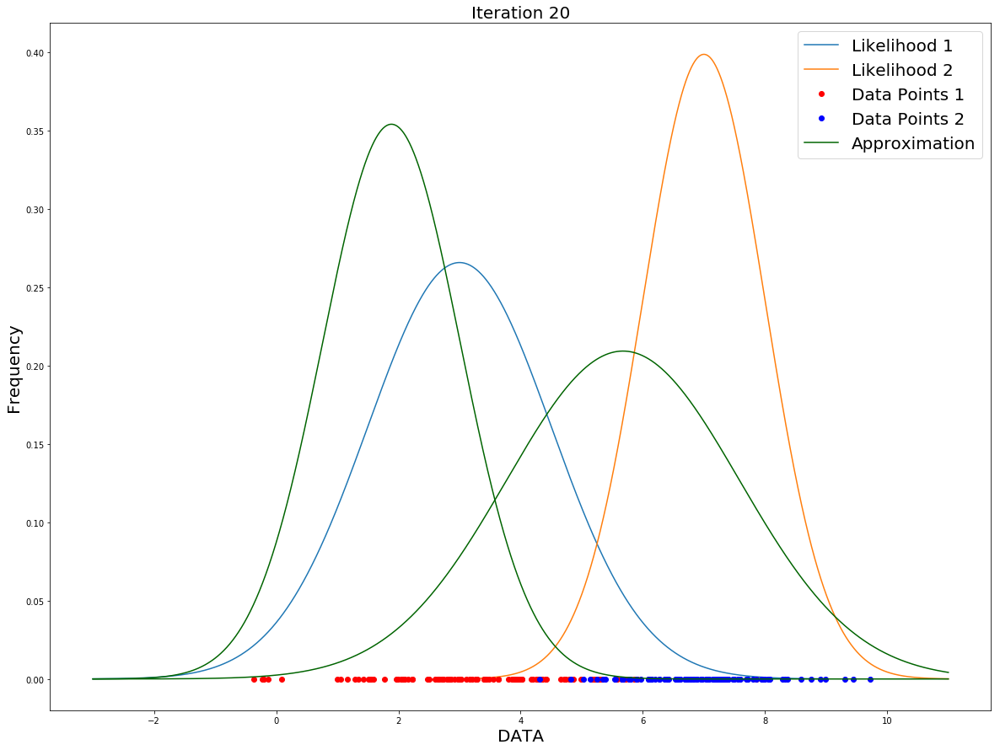

2.3008059166167873 6.105429557698245
1.2059741776673183 1.6113124202934244


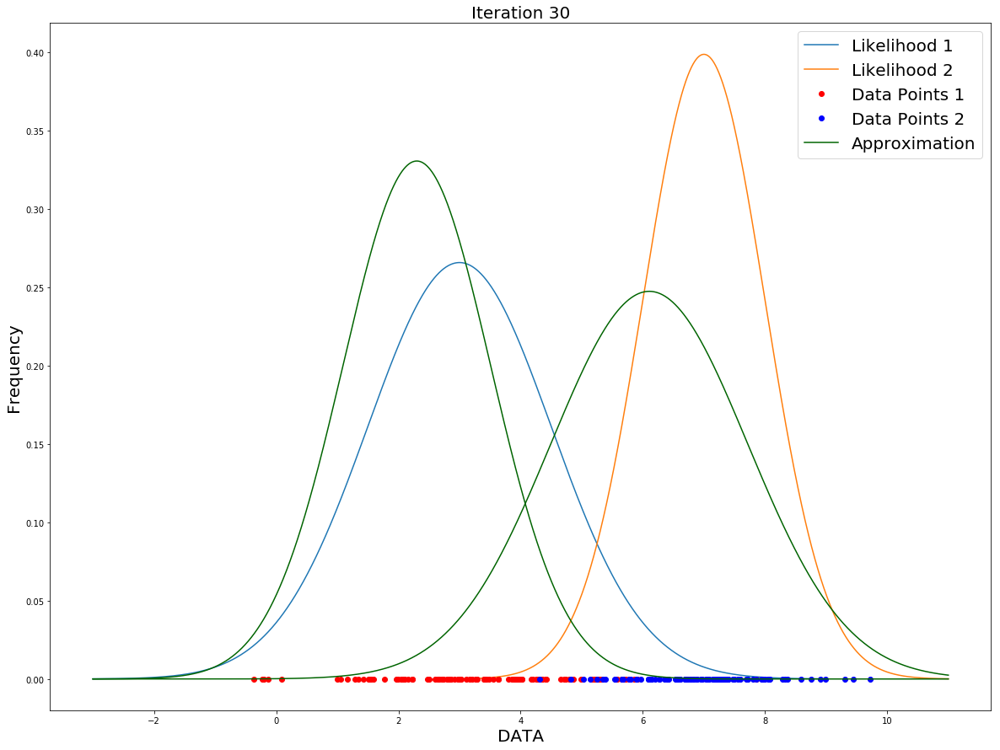

2.6945926438704118 6.469030285192448
1.3089033686803149 1.3606711397716826


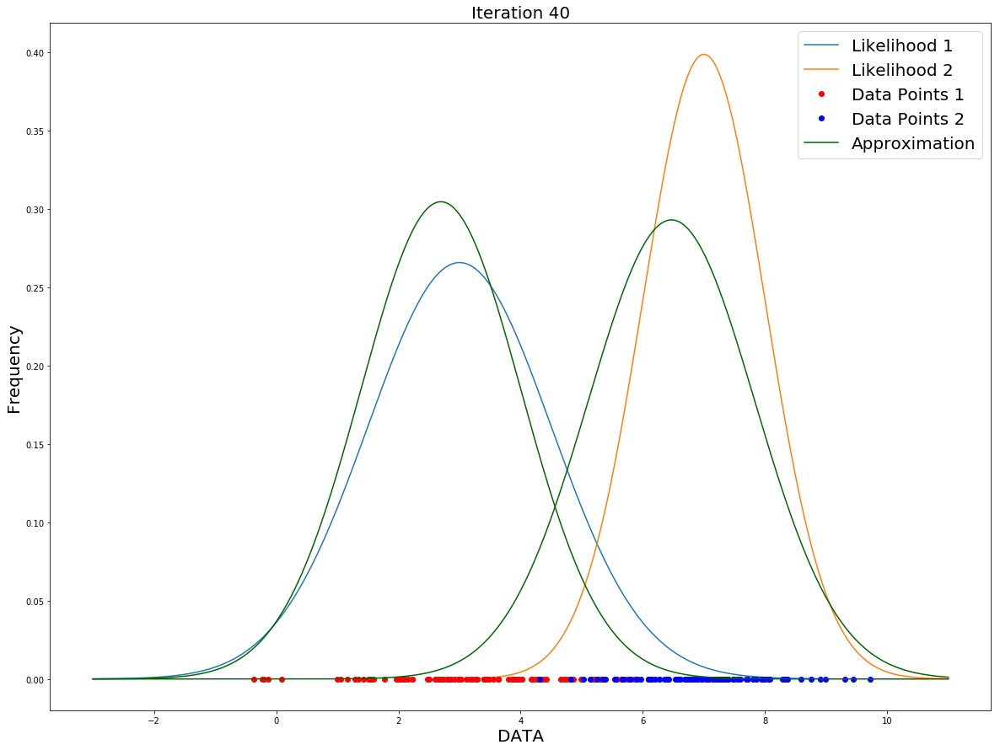

2.9762852803342437 6.700327576194317
1.4177499209938829 1.200751589148063


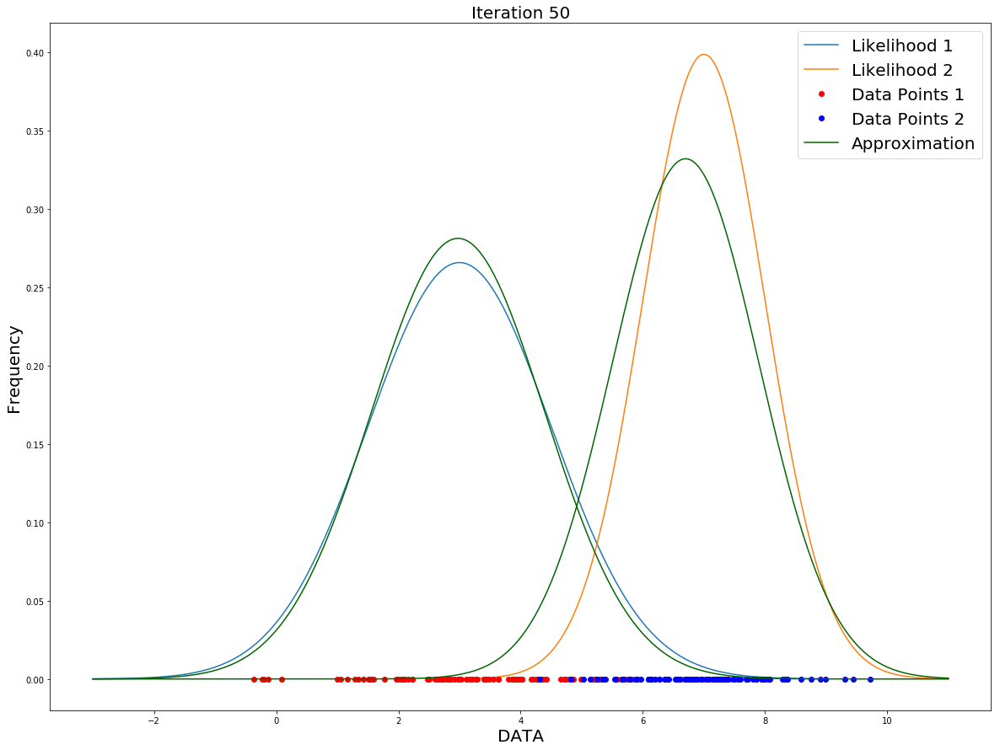

3.1454598683077526 6.812890910447165
1.500607200602801 1.1296669370444878


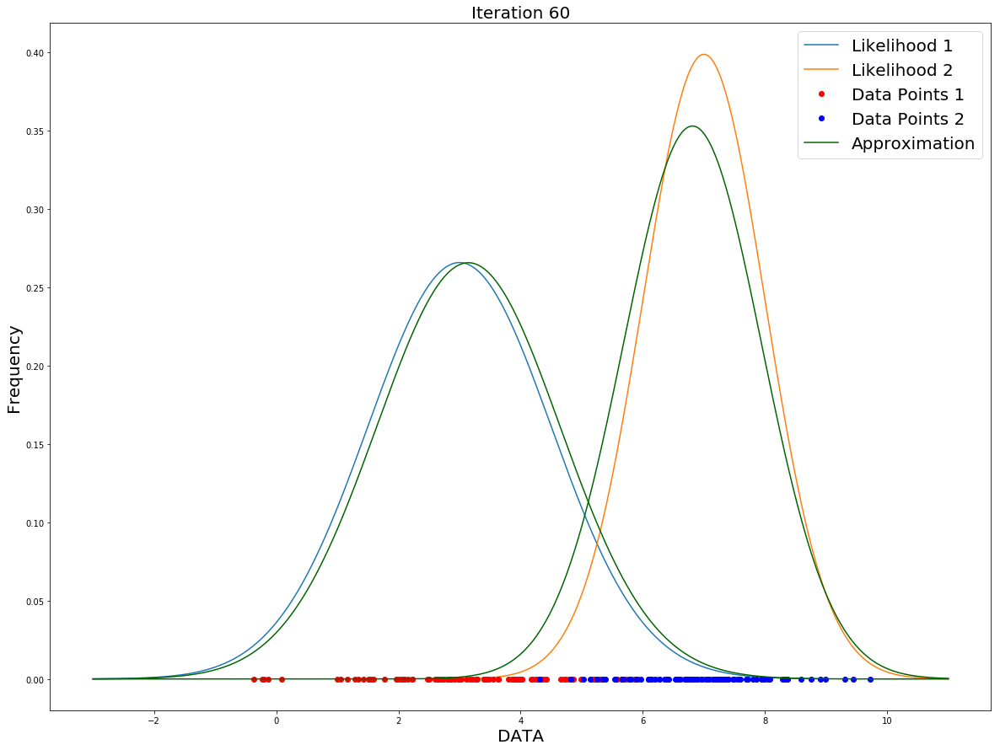

3.2394417613228774 6.866422347999861
1.5507107891704495 1.099140287441019


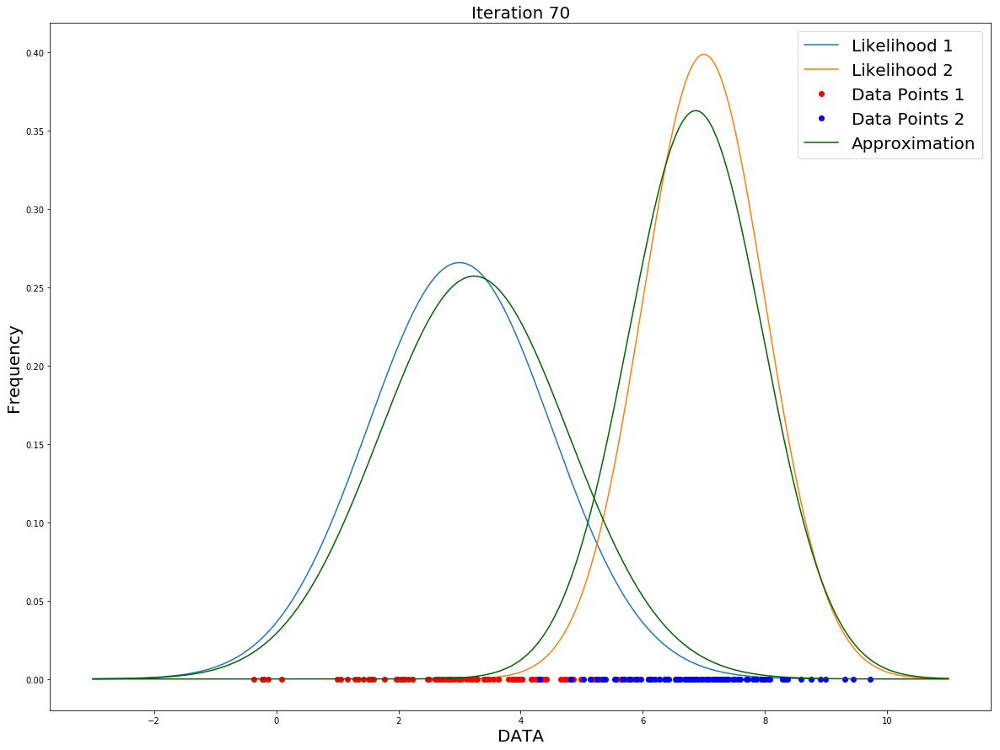

3.2919397423168273 6.893960827816468
1.5794543558618994 1.084304990048572


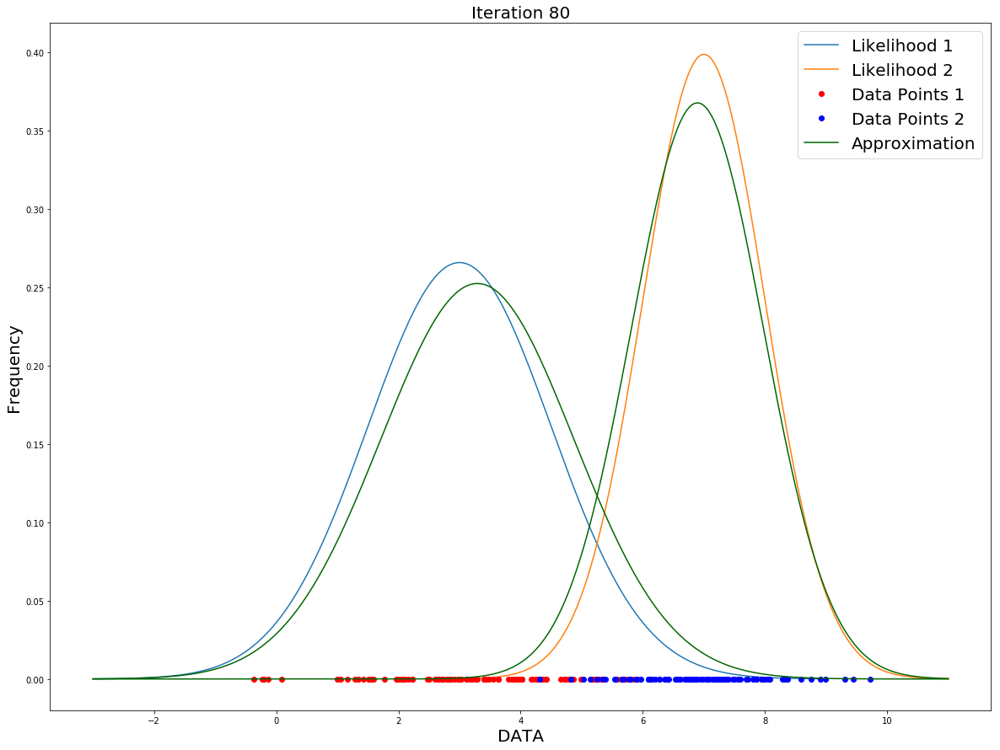

3.3219014324785863 6.908999880460017
1.5960219684994656 1.0764249125805312


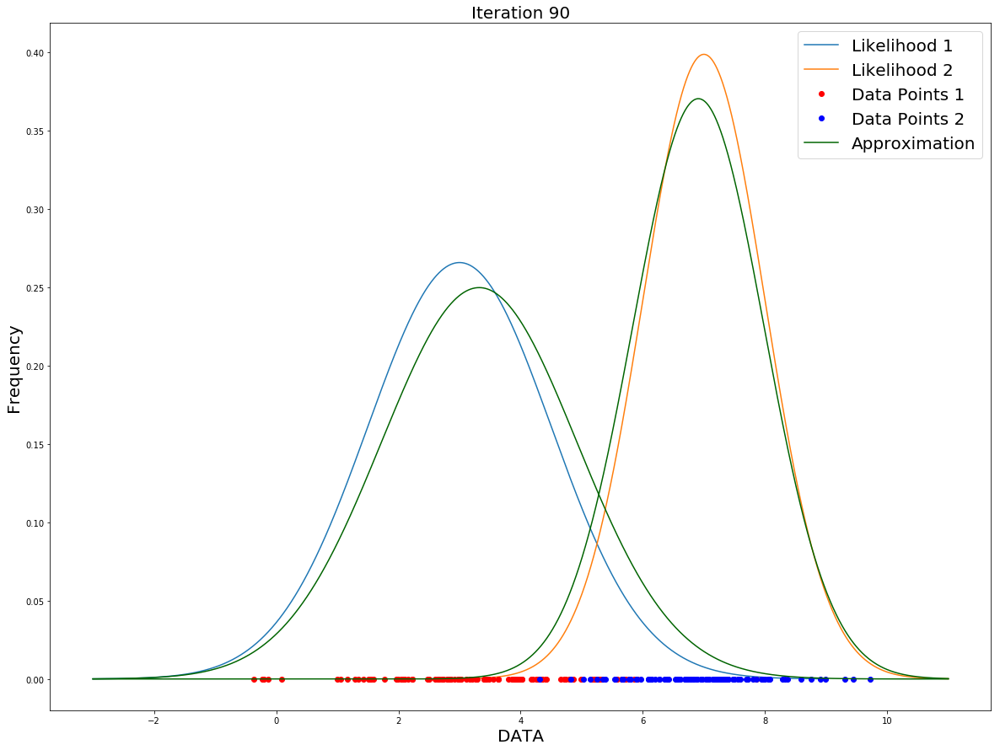

3.339291311881206 6.917515500348519
1.6056798998883677 1.0720242957700923


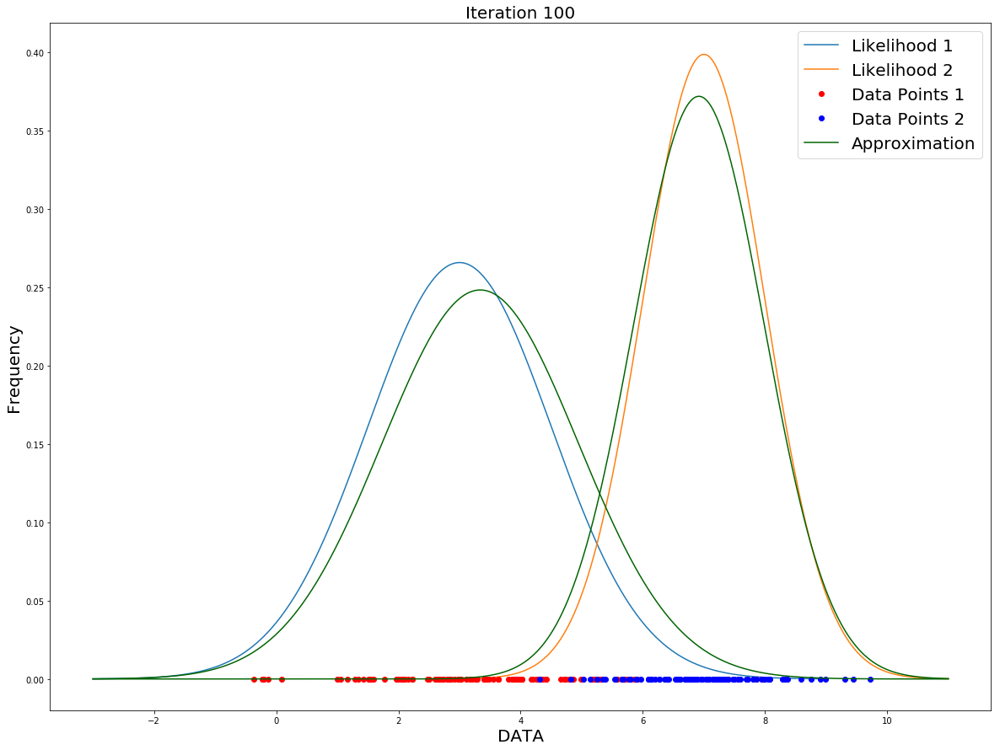

In [13]:
from sklearn import cluster, datasets, mixture
from scipy.stats import multivariate_normal

N_iter = 100
bins = np.linspace(np.min(X_approx),np.max(X_approx), 10000)
for step in range(N_iter + 1):
    if step % 10 == 0:
        
        plt.figure(figsize = (20, 15))
        plt.ylabel('Frequency', fontsize = 20)
        plt.xlabel('DATA', fontsize = 20)
        plt.title("Iteration {}".format(step), fontsize = 20)
        
        plt.plot(x1_approx, pdf(x1_approx, mu1, sigma1))
        plt.plot(x2_approx, pdf(x2_approx, mu2, sigma2))
        
        plt.plot(x1, list(0 for i in range(0, len(list(x1)))), 'ro')
        plt.plot(x2, list(0 for i in range(0, len(list(x2)))), 'bo')

        
        print(means[0], means[1])
        print(sigmas[0], sigmas[1])
        
        plt.plot(bins, pdf(bins, means[0], sigmas[0]), color = 'darkgreen')
        plt.plot(bins, pdf(bins, means[1], sigmas[1]), color = 'darkgreen')
    
        plt.legend(['Likelihood 1', 'Likelihood 2','Data Points 1', 'Data Points 2', 'Approximation'], 
                   loc = 'upper right', fontsize = 20)
        plt.show()
    
    # Expectation step
    likelihood = []
    for j in range(k):
        likelihood.append(pdf(X, means[j], sigmas[j]))
    
    # Maximization step
    posterior = []
    for j in range(k):
        posterior.append((likelihood[j] * priors[j]) / (np.sum([likelihood[i] * priors[i] for i in range(k)], 
                                                        axis = 0)))
        means[j] = np.sum(posterior[j] * X) / np.sum(posterior[j])
        sigmas[j] = np.sqrt(np.sum(posterior[j] * np.square(X - means[j])) / np.sum(posterior[j]))
        priors[j] = np.mean(priors[j])

#### Probabilistic Interpretation of GMM and AIC <a class="anchor" id="Probabilistic-Interpretation-of-GMM-and-AIC"></a>

Since GMM outputs a probability for each data point to be assigned to a cluster, this can be used in the Akaike Information Criterion (AIC) that balances the goodness of fit and the number of fitting parameters, that is the number of clusters.

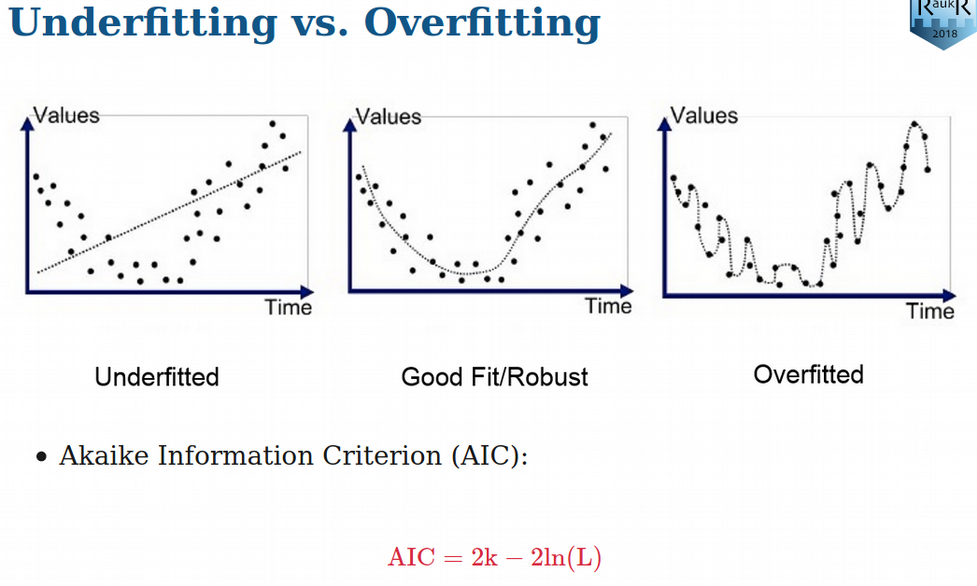

In [24]:
from IPython.display import Image
Image('/home/nikolay/WABI/MO_Melander/Presentation/AIC.png', width = 2000)

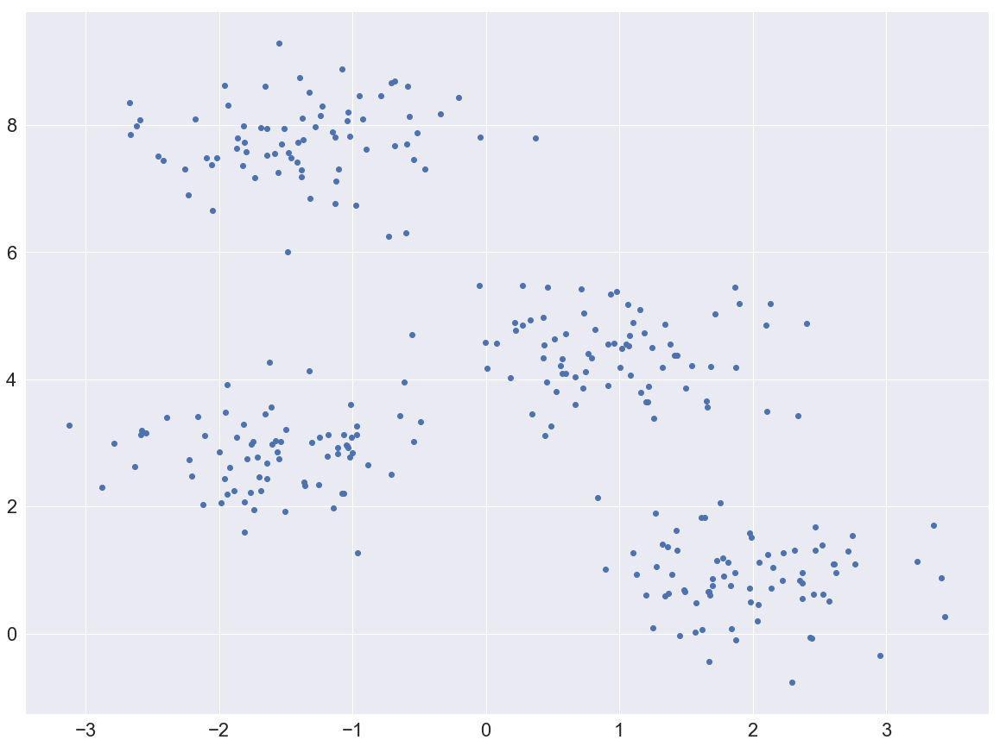

In [30]:
import numpy as np
from sklearn.datasets.samples_generator import make_blobs
from sklearn.mixture import GaussianMixture
from matplotlib import pyplot as plt
import seaborn as sns
sns.set(font_scale=2)

plt.figure(figsize = (20, 15))
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
plt.scatter(X[:,0], X[:,1])
plt.show()

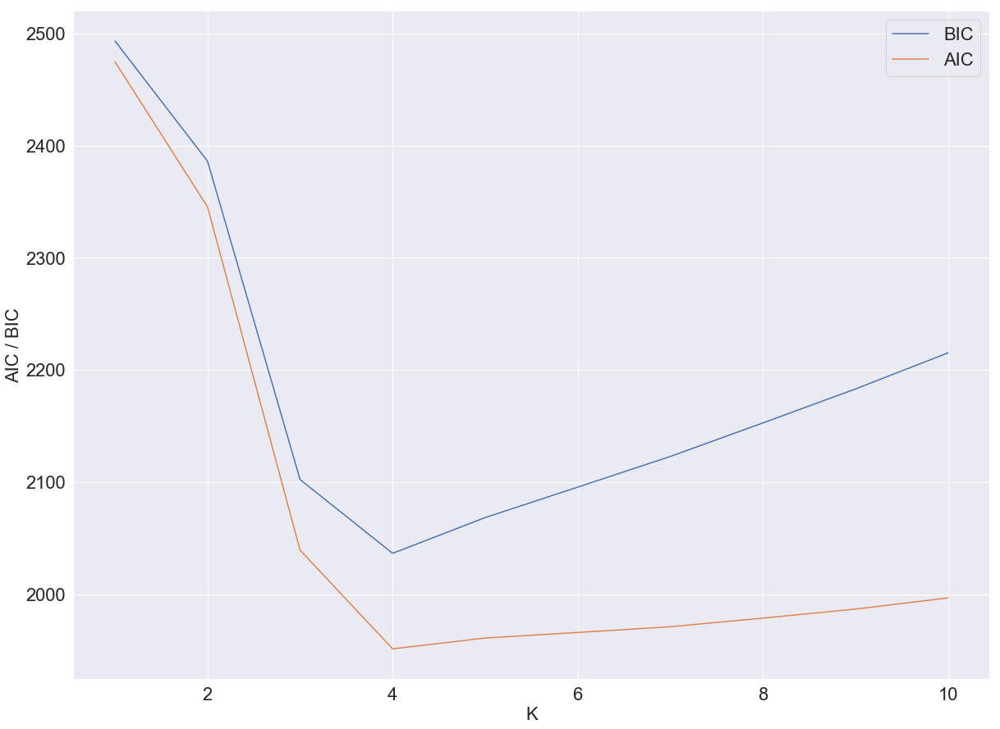

In [31]:
n_components = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(X) for n in n_components]

plt.figure(figsize = (20, 15))
plt.plot(n_components, [m.bic(X) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X) for m in models], label='AIC')
plt.legend(loc='best', fontsize = 22)
plt.xlabel('K', fontsize = 22)
plt.ylabel('AIC / BIC', fontsize = 22)
plt.show()